In [61]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [62]:
# Load the CSV dataset 
df = pd.read_csv("Industrial_Innovation_Tracker_Merged.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1637, 6)


,Country Name,Country Code,Year,R&D_Expenditure_%GDP,Researchers_per_Million,Patent_Applications
0,Australia,AUS,1996,1.66218,3353.70530,1797.0
1,Belgium,BEL,1996,1.74299,2477.43906,776.0
2,Bulgaria,BGR,1996,0.41826,1771.85422,316.0
3,Canada,CAN,1996,1.60682,3055.67247,2583.0
4,Switzerland,CHE,1996,2.37649,3130.03604,2504.0


In [63]:
# Define features and target 
X = df[["R&D_Expenditure_%GDP", "Researchers_per_Million"]]
y = df["Patent_Applications"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1637, 2)
Target shape: (1637,)


In [64]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1309
Testing samples: 328


In [65]:
#Model Training
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [66]:
#Model Predictions
y_pred = model.predict(X_test)

y_pred[:5]

array([  58568.3450332 , -104534.560083  ,  100451.59089981,
         44781.15758531,   12954.96138504])

In [67]:
#Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("===== MODEL EVALUATION RESULTS =====")
print("R² Score :", round(r2, 4))
print("MSE      :", round(mse, 4))
print("RMSE     :", round(rmse, 4))
print("MAE      :", round(mae, 4))

===== MODEL EVALUATION RESULTS =====
R² Score : 0.3454
MSE      : 27234177903.5356
RMSE     : 165027.8095
MAE      : 91028.2909


In [68]:
# Train vs Test Performance (Overfitting Check)
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R² :", round(train_r2, 4))
print("Test R²  :", round(test_r2, 4))

Train R² : 0.2985
Test R²  : 0.3454


In [69]:
#Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross Validation R² Scores:", cv_scores)
print("Average CV R²:", round(cv_scores.mean(), 4))

Cross Validation R² Scores: [-0.03124316  0.2651434   0.33426757  0.32414199  0.28225523]
Average CV R²: 0.2349


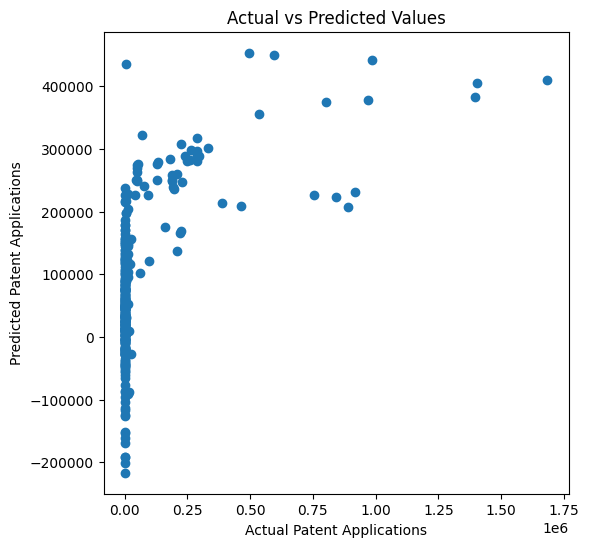

In [70]:
# Visualization(Actual vs Predicted)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Patent Applications")
plt.ylabel("Predicted Patent Applications")
plt.title("Actual vs Predicted Values")
plt.show()

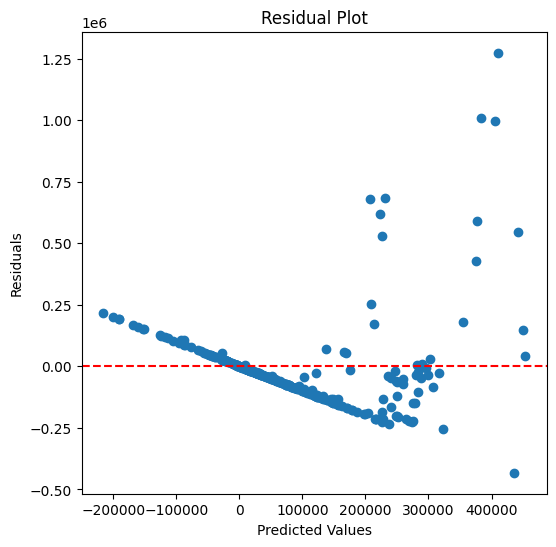

In [71]:
# Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()